In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from data_source import YahooFinanceDataSource

data_source = YahooFinanceDataSource()
holdings_df = data_source.read_spy_holdings('holdings-daily-us-en-spy.xlsx')
print(f"Found {len(holdings_df)} constituent stocks in SPY ETF.")
# test on 2 months. Note: SNDK was added to S&P500 on 2/14 so not available with these weights. Test still passes with good spearman
end_date = '2026-01-04'  
start_date = '2025-01-04'  
# replace holdings_df ticker BRK.B with BRK-B and BF.B with BF-B, and '-' with USD
holdings_df['Ticker'] = holdings_df['Ticker'].replace({
    'BRK.B': 'BRK-B',
    'BF.B': 'BF-B',
    '-': 'USD'
})
tickers = ['SPY'] + holdings_df['Ticker'].tolist()
print(f"Fetching historical data for SPY and {len(tickers)-1} constituents...")


Found 505 constituent stocks in SPY ETF.
Fetching historical data for SPY and 505 constituents...


In [4]:
price_data = data_source.get_historical_data(tickers, start_date, end_date)
if 'SPY' not in price_data.columns:
    print("Error: SPY data not found in the downloaded data.")
spy_data = price_data['SPY'].copy()
valid_columns = list(price_data.columns[price_data.isna().sum() == 0])

if 'SPY' not in valid_columns and 'SPY' in price_data.columns:
    valid_columns.append('SPY')

price_data = price_data[valid_columns]

valid_constituents = [ticker for ticker in valid_columns if ticker != 'SPY']
print(f"Found valid data for {len(valid_constituents)} out of {len(holdings_df)} constituents.")

print("Calculating weighted portfolio from constituents...")
weighted_portfolio = data_source.calculate_weighted_portfolio(holdings_df, price_data)

print("Verifying SPY returns against weighted constituent returns...")
verification_results = data_source.verify_spy_vs_constituents(
    spy_data,  
    weighted_portfolio, 
    threshold=0.01
)

status = "PASSED" if verification_results['within_threshold'] else "FAILED"
print(f"\nVerification {status}")
print(f"Maximum difference: {verification_results['max_difference']*100:.4f}%")
print(f"Mean difference: {verification_results['mean_difference']*100:.4f}%")
print(f"Spearman Coefficient: {verification_results['spearman_coeff']*100:.4f}%")

[****                   8%                       ]  39 of 506 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
[****                   9%                       ]  45 of 506 completed$PARA: possibly delisted; no timezone found
[********              17%                       ]  87 of 506 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
[*********             18%                       ]  92 of 506 completed$WBA: possibly delisted; no timezone found
[*****************     35%                       ]  177 of 506 completed$K: possibly delisted; no timezone found
[**********************47%                       ]  238 of 506 completed$DFS: possibly delisted; no timezone found
[**********************53%                       ]  269 of 506 completed$ANSS: possibly delisted; no timezone found
[**********************55%*     

Found valid data for 493 out of 505 constituents.
Calculating weighted portfolio from constituents...
Verifying SPY returns against weighted constituent returns...

Verification FAILED
Maximum difference: 1.3603%
Mean difference: 0.0758%
Spearman Coefficient: 99.4409%


In [5]:
def plot_comparison(spy_returns: pd.Series, portfolio_returns: pd.Series, title: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    ax1.plot(spy_returns.index, spy_returns, label='SPY', color='blue')
    ax1.plot(portfolio_returns.index, portfolio_returns, label='Weighted Portfolio', color='orange')
    ax1.set_title(f"{title} - Daily")
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Daily Return')
    ax1.legend()
    ax1.grid(True)
    
    cum_spy = (1 + spy_returns).cumprod()
    cum_portfolio = (1 + portfolio_returns).cumprod()
    
    ax2.plot(cum_spy.index, cum_spy, label='SPY', color='blue')
    ax2.plot(cum_portfolio.index, cum_portfolio, label='Weighted Portfolio', color='orange')
    ax2.set_title(f"{title} - Cumulative")
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Cumulative Return')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('spy_verification_results.png')
    print("Saved comparison plot to 'spy_verification_results.png'")


Saved comparison plot to 'spy_verification_results.png'


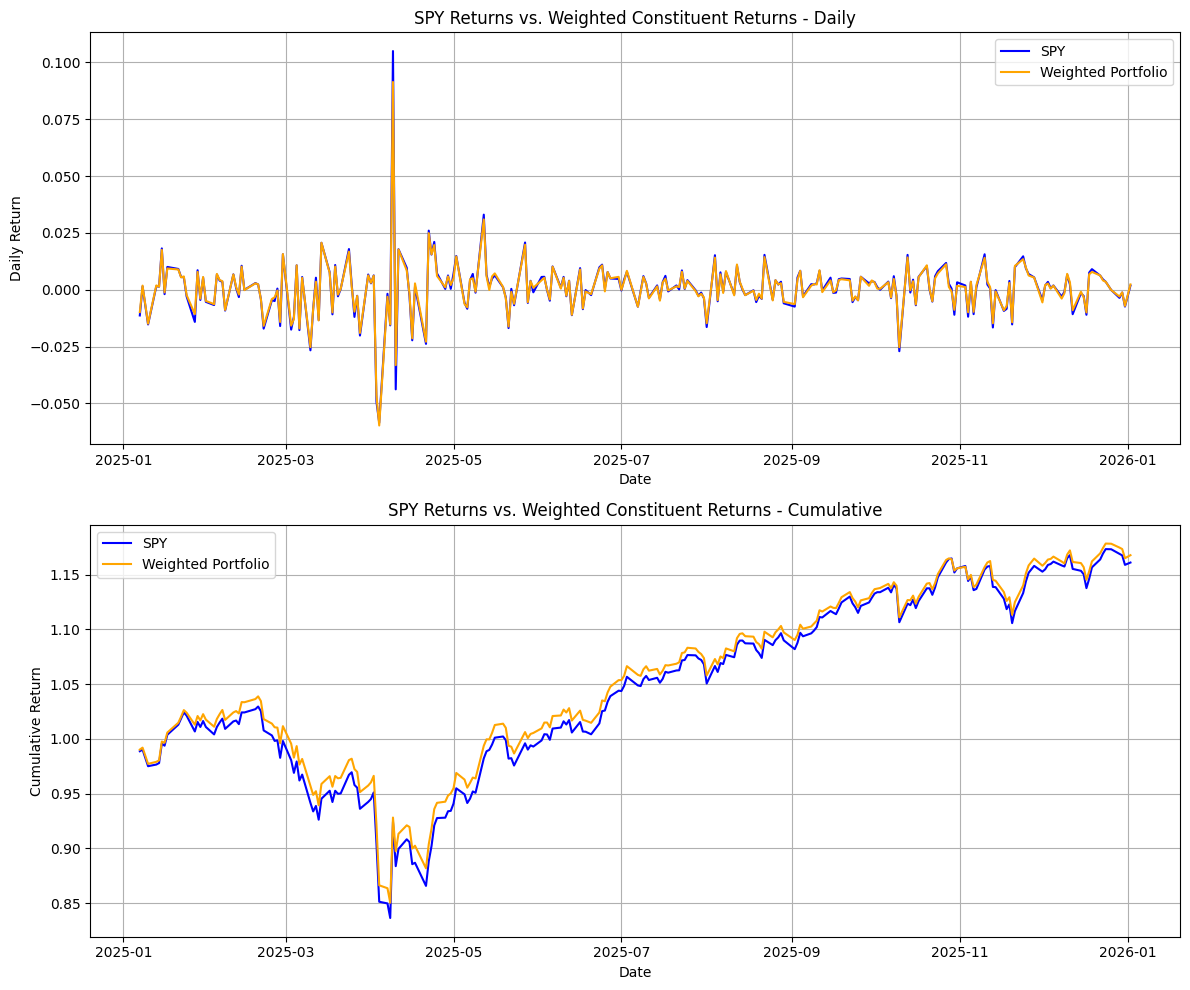

In [6]:
plot_comparison(
    verification_results['spy_returns'], 
    verification_results['portfolio_returns'],
    'SPY Returns vs. Weighted Constituent Returns'
)

In [7]:
from data_source import YahooFinanceDataSource
from order_generator import OrderGenerator
from metrics import ExtendedMetrics
from backtest_engine import EquityBacktestEngine 
import pandas as pd
import matplotlib.pyplot as plt

class WeightedOrderGenerator(OrderGenerator):
    """
    Uses holdings weights for order sizing.
    For each ticker from holdings_df (excluding SPY), a BUY is generated on the common start date 
    and a SELL on the common end date.
    The order quantity is computed as:
         quantity = (initial_cash * normalized_weight) / price_on_common_start
    using float arithmetic to preserve exposure.
    """
    def __init__(self, holdings_df: pd.DataFrame, initial_cash: float):
        self.holdings_df = holdings_df.copy()
        self.initial_cash = initial_cash
        total_weight = self.holdings_df['Weight'].sum()
        # normalizing shouldn't impact weights
        self.holdings_df['NormalizedWeight'] = self.holdings_df['Weight'] / total_weight
        
    def generate_orders(self, price_data: pd.DataFrame) -> list:
        orders = []
        # Use common start and end dates for all tickers
        common_start = price_data.index[0]
        common_end = price_data.index[-1]
        for ticker in self.holdings_df['Ticker']:
            if ticker not in price_data.columns:
                continue
            # Since price_data has been filtered for valid columns, every ticker has data on common_start
            first_price = price_data.at[common_start, ticker]
            norm_weight = self.holdings_df.loc[self.holdings_df['Ticker'] == ticker, 'NormalizedWeight'].iloc[0]
            allocated_cash = self.initial_cash * norm_weight
            quantity = allocated_cash / first_price
            if quantity <= 0:
                continue
            orders.append({
                "date": common_start,
                "type": "BUY",
                "ticker": ticker,
                "quantity": quantity
            })
            orders.append({
                "date": common_end,
                "type": "SELL",
                "ticker": ticker,
                "quantity": quantity
            })
        return sorted(orders, key=lambda o: o["date"])


class SimpleOrderGenerator(OrderGenerator):
    """
    Creates two orders (BUY then SELL) for each ticker in the provided data.
    For SPY-only strategy, the quantity is computed as the full allocation:
         quantity = initial_cash / price_on_common_start
    using float arithmetic.
    """
    def generate_orders(self, data: pd.DataFrame) -> list:
        orders = []
        common_start = data.index[0]
        common_end = data.index[-1]
        for ticker in data.columns:
            series = data[ticker].dropna()
            if series.empty:
                continue
            first_price = data.at[common_start, ticker]
            quantity = 100_000 / first_price  # using full initial cash
            orders.append({
                "date": common_start,
                "type": "BUY",
                "ticker": ticker,
                "quantity": quantity
            })
            orders.append({
                "date": common_end,
                "type": "SELL",
                "ticker": ticker,
                "quantity": quantity
            })
        return sorted(orders, key=lambda o: o["date"])

In [8]:
data_source = YahooFinanceDataSource()
holdings_file = 'holdings-daily-us-en-spy.xlsx'
holdings_df = data_source.read_spy_holdings(holdings_file)
print(f"Found {len(holdings_df)} constituent stocks in SPY ETF.")
holdings_df['Ticker'] = holdings_df['Ticker'].replace({
    'BRK.B': 'BRK-B',
    'BF.B': 'BF-B',
    '-': 'USD'
})
tickers = ['SPY'] + holdings_df['Ticker'].tolist()
print(f"Fetching historical data for SPY and {len(tickers)-1} constituents...")

start_date = '2025-01-04'
end_date = '2026-01-04'
price_data = data_source.get_historical_data(tickers, start_date, end_date)

valid_columns = list(price_data.columns[price_data.isna().sum() == 0])
if 'SPY' not in valid_columns and 'SPY' in price_data.columns:
    valid_columns.append('SPY')
price_data = price_data[valid_columns]

initial_cash = 100_000

weighted_og = WeightedOrderGenerator(holdings_df, initial_cash)
orders_weighted = weighted_og.generate_orders(price_data)
print(f"Generated {len(orders_weighted)} weighted orders for holdings tickers.")

price_data_spy = price_data[['SPY']].copy()
simple_og = SimpleOrderGenerator()
orders_spy = simple_og.generate_orders(price_data_spy)
print(f"Generated {len(orders_spy)} orders for SPY only.")

Found 505 constituent stocks in SPY ETF.
Fetching historical data for SPY and 505 constituents...


[****                   8%                       ]  43 of 506 completed$PARA: possibly delisted; no timezone found
[********              17%                       ]  84 of 506 completed$WBA: possibly delisted; no timezone found
[*****************     36%                       ]  183 of 506 completed$K: possibly delisted; no timezone found
[**********************47%                       ]  238 of 506 completed$DFS: possibly delisted; no timezone found
[**********************55%*                      ]  277 of 506 completed$ANSS: possibly delisted; no timezone found
[**********************56%**                     ]  284 of 506 completed$IPG: possibly delisted; no timezone found
[**********************56%**                     ]  285 of 506 completed$MMC: possibly delisted; no timezone found
[**********************64%******                 ]  326 of 506 completed$HES: possibly delisted; no timezone found
[**********************65%******                 ]  327 of 506 completed$DAY: poss

Generated 986 weighted orders for holdings tickers.
Generated 2 orders for SPY only.


In [9]:
engine = EquityBacktestEngine(initial_cash=initial_cash)

backtest_result_weighted = engine.run_backtest(orders_weighted, price_data)
portfolio_weighted = backtest_result_weighted['portfolio_values']
returns_weighted = portfolio_weighted['Portfolio Value'].pct_change().dropna()

backtest_result_spy = engine.run_backtest(orders_spy, price_data_spy)
portfolio_spy = backtest_result_spy['portfolio_values']
returns_spy = portfolio_spy['Portfolio Value'].pct_change().dropna()

common_index = returns_weighted.index.intersection(returns_spy.index)
returns_weighted_aligned = returns_weighted.loc[common_index]
returns_spy_aligned = returns_spy.loc[common_index]

returns_df = pd.DataFrame({
    'Weighted Holdings': returns_weighted_aligned,
    'SPY Only': returns_spy_aligned
})

# print final vals of returns
print(f"Final value of Weighted Holdings: {portfolio_weighted['Portfolio Value'].iloc[-1]:.2f}")
print(f"Final value of SPY Only: {portfolio_spy['Portfolio Value'].iloc[-1]:.2f}")

2025-01-06 00:00:00: Portfolio Value - 100000.00
2025-01-07 00:00:00: Portfolio Value - 99025.81
2025-01-08 00:00:00: Portfolio Value - 99204.92
2025-01-10 00:00:00: Portfolio Value - 97736.31
2025-01-13 00:00:00: Portfolio Value - 97921.66
2025-01-14 00:00:00: Portfolio Value - 98052.52
2025-01-15 00:00:00: Portfolio Value - 99757.76
2025-01-16 00:00:00: Portfolio Value - 99644.21
2025-01-17 00:00:00: Portfolio Value - 100568.72
2025-01-21 00:00:00: Portfolio Value - 101457.91
2025-01-22 00:00:00: Portfolio Value - 102005.54
2025-01-23 00:00:00: Portfolio Value - 102599.50
2025-01-24 00:00:00: Portfolio Value - 102364.91
2025-01-27 00:00:00: Portfolio Value - 101277.88
2025-01-28 00:00:00: Portfolio Value - 102065.89
2025-01-29 00:00:00: Portfolio Value - 101668.94
2025-01-30 00:00:00: Portfolio Value - 102234.28
2025-01-31 00:00:00: Portfolio Value - 101738.18
2025-02-03 00:00:00: Portfolio Value - 101099.27
2025-02-04 00:00:00: Portfolio Value - 101797.57
2025-02-05 00:00:00: Portfo


Spearman Correlation between weighted holdings and SPY-only daily returns:
  99.4394%
Standard Deviation of individual strategies:
  Weighted Holdings: 1.1234%
  SPY Only: 1.2297%
Standard Deviation of the difference in daily returns: 0.1470%

Saved cumulative returns plot as 'weighted_vs_spy_cumulative_returns.png'


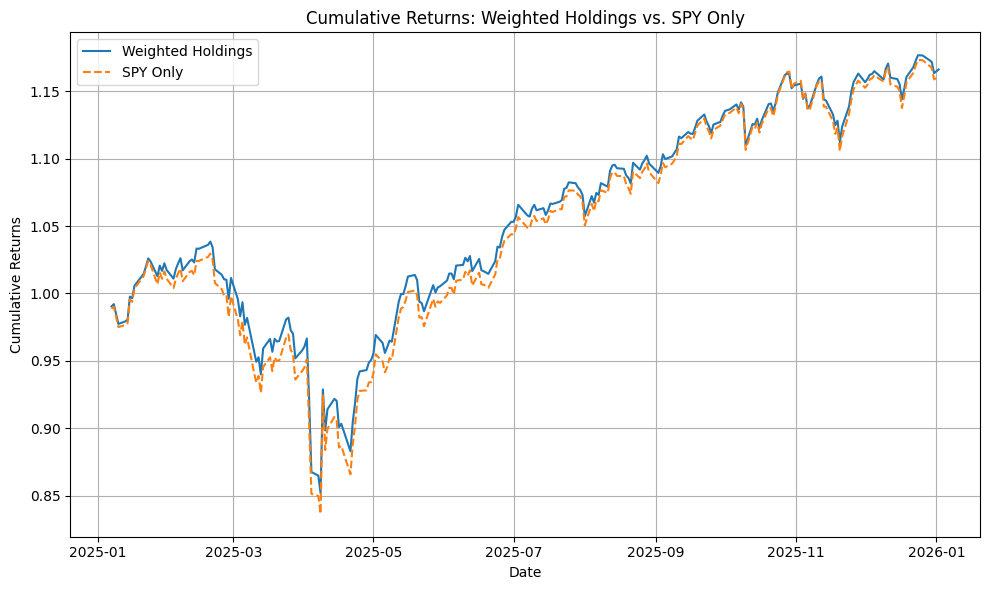

In [10]:
spearman_corr = returns_df.corr(method='spearman').iloc[0, 1]
print(f"\nSpearman Correlation between weighted holdings and SPY-only daily returns:")
print(f"  {spearman_corr*100:.4f}%")
return_difference = returns_df['Weighted Holdings'] - returns_df['SPY Only']
std_difference = return_difference.std()
print(f"Standard Deviation of individual strategies:")
print(f"  Weighted Holdings: {returns_df['Weighted Holdings'].std()*100:.4f}%")
print(f"  SPY Only: {returns_df['SPY Only'].std()*100:.4f}%")
print(f"Standard Deviation of the difference in daily returns: {std_difference*100:.4f}%")

cum_returns_weighted = (1 + returns_weighted_aligned).cumprod()
cum_returns_spy = (1 + returns_spy_aligned).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(cum_returns_weighted.index, cum_returns_weighted, label='Weighted Holdings')
plt.plot(cum_returns_spy.index, cum_returns_spy, label='SPY Only', linestyle='--')
plt.title('Cumulative Returns: Weighted Holdings vs. SPY Only')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("weighted_vs_spy_cumulative_returns.png")
print("\nSaved cumulative returns plot as 'weighted_vs_spy_cumulative_returns.png'")
plt.show()

#### Drawbacks of the Current Backtest (BT) in the Notebook
- No slippage/transaction costs
- Survivorship bias (we're only modeling stocks in S&P who have technically 'survived' until this period in time)
- If not careful with shifts, can introduce look-ahead bias
- Slight difference from our weighted price vs. SPY due to approximations in weighting by the dataset we got weights from, not accounting friction of trades (consolidating a huge position of an ETF requires money and a management fee)
- Our fully weighted portfolio factors 0 friction, so we expect a higher return. SPY's expense ratio is roughly 0.09%, which is close to the std dev diff between weighted and SPY only.
- No liquidity constraints on our positions 

#### How To Improve Signal Construction and Backtesting
- Out of sample testing
- Sensitivity tests for params of our model (for example, how sensitive is mom. to window size??)
- Add smoothing for noise if testing on noisy data and winsorize
- Ensure stationarity of our data before testing
- Kalman filter potentially to remove noisy data
- Implement a way to run factor decomposition on our implementations
- Implement a correlation calculator for multiple factors in our backtest engine

## Unified SPY Replication: Yahoo vs Wharton (Same Window)


Loading SPY ETF holding weights...
Using shared window: 2023-01-01 to 2024-01-01
Fetching Yahoo data for 506 tickers...


[*                      3%                       ]  15 of 506 completed$WBA: possibly delisted; no timezone found
[*****                 11%                       ]  57 of 506 completed$JNPR: possibly delisted; no timezone found
[****************      34%                       ]  173 of 506 completed$SOLV: possibly delisted; no price data found  (1d 2023-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1704085200")
[******************    37%                       ]  187 of 506 completed$IPG: possibly delisted; no timezone found
[********************  42%                       ]  215 of 506 completed$HES: possibly delisted; no timezone found
[**********************73%**********             ]  369 of 506 completed$GEV: possibly delisted; no price data found  (1d 2023-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1704085200")
[**********************73%**********             ]  370 of 506 completed

Saved Yahoo cache: cache/yahoo_prices_2023_2024.parquet
Initializing WhartonDataSource (default -> WhartonDataSource4)...
WhartonDataSource loaded 4232706 records for 831 tickers from /Users/bouse/developer/CDS/millennium-data-quality-25-26/backtester/WhartonDataSource4.parquet
Fetching Wharton data for 506 tickers...
Saved Wharton cache: cache/wharton_prices_2023_2024.parquet

--- Yahoo Performance Metrics ---
Verification: FAILED
Complete constituents used: 489
Dropped (missing/partial): 16
Max Difference: 2.4578%
Mean Difference: 0.2871%
Spearman Coeff: 94.4166%
Pearson Coeff: 94.4828%

--- Wharton Performance Metrics ---
Verification: FAILED
Complete constituents used: 495
Dropped (missing/partial): 10
Max Difference: 2.4492%
Mean Difference: 0.2859%
Spearman Coeff: 94.4470%
Pearson Coeff: 94.5233%

--- Wharton Discrepancy Diagnostics ---
Wharton missing/partial constituents: 10
Missing/partial list: ['BF.B', 'FI', 'GEV', 'KVUE', 'MMC', 'PARA', 'SNDK', 'SOLV', 'SW', 'VLTO']
Wharton

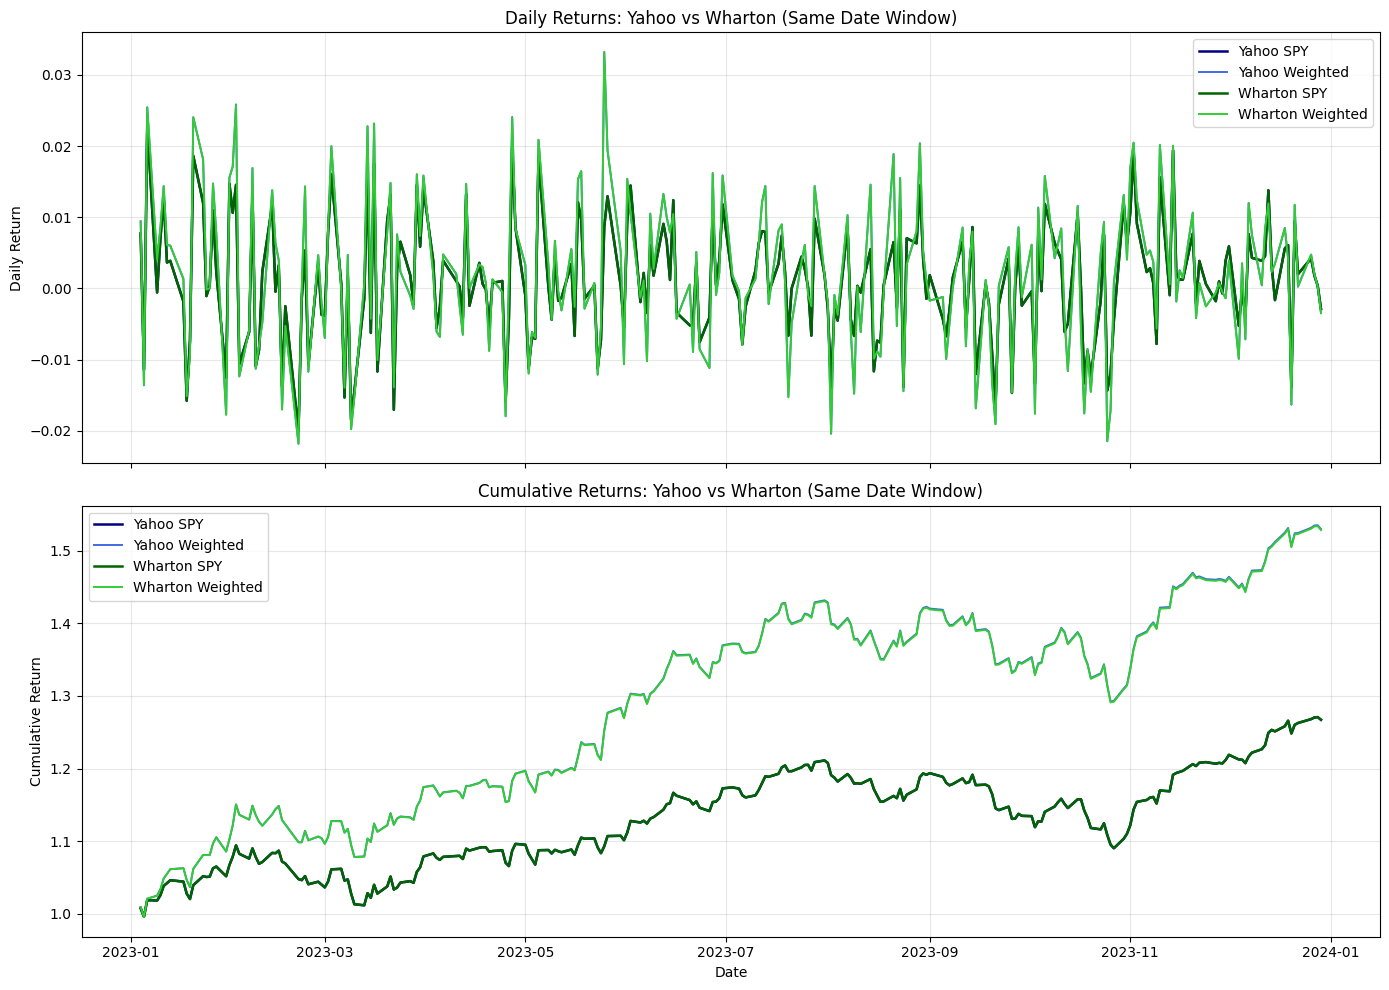

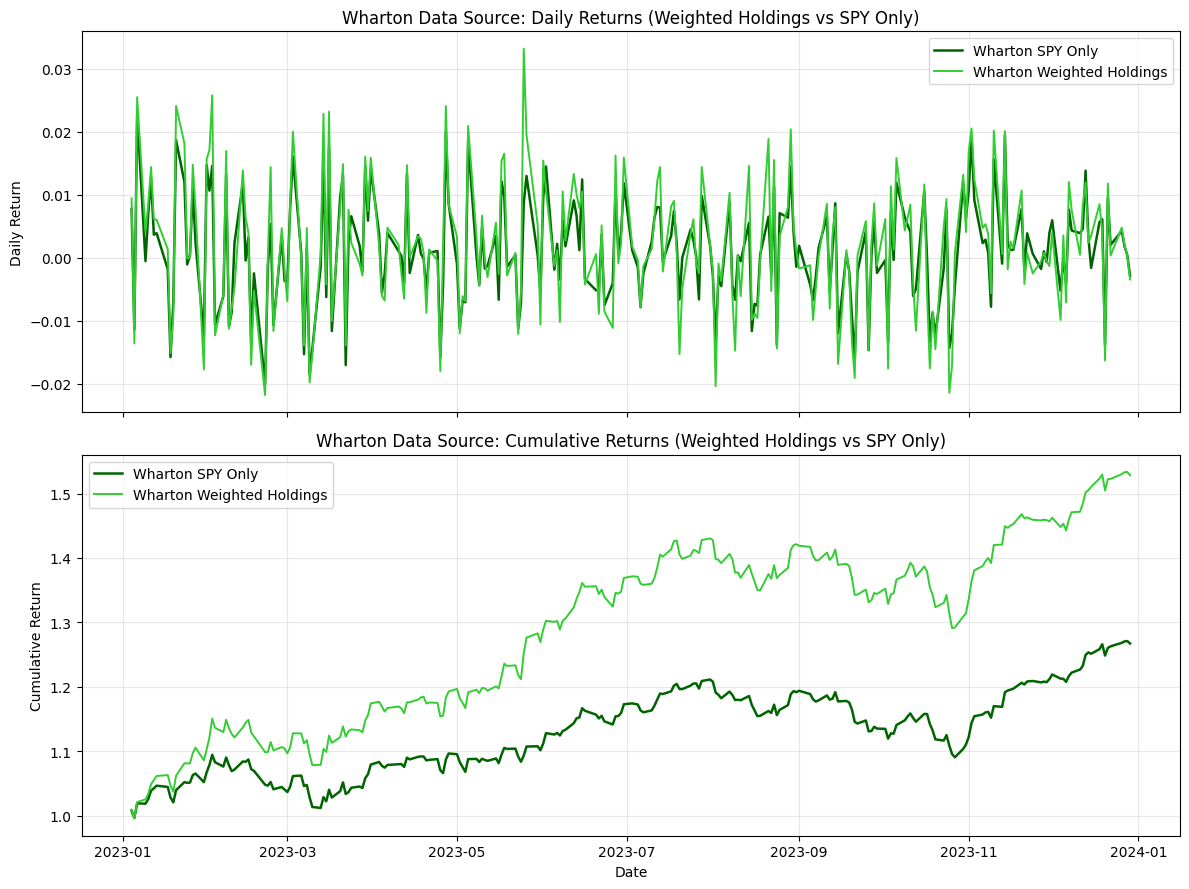

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from data_source import WhartonDataSource, YahooFinanceDataSource


def run_verification(price_data: pd.DataFrame, holdings_df: pd.DataFrame, label: str, threshold: float = 0.01):
    if 'SPY' not in price_data.columns:
        raise ValueError(f"{label}: SPY data not found")

    spy_data = price_data['SPY'].copy()
    valid_columns = list(price_data.columns[price_data.isna().sum() == 0])
    if 'SPY' not in valid_columns:
        valid_columns.append('SPY')

    price_data = price_data[valid_columns]
    valid_constituents = [t for t in valid_columns if t != 'SPY']

    weighted_portfolio = yf_ds.calculate_weighted_portfolio(holdings_df, price_data)
    verification = yf_ds.verify_spy_vs_constituents(spy_data, weighted_portfolio, threshold=threshold)

    spy_returns = spy_data.pct_change().dropna()
    portfolio_returns = weighted_portfolio.pct_change().dropna()
    common_dates = spy_returns.index.intersection(portfolio_returns.index)

    return {
        'label': label,
        'spy': spy_data.loc[common_dates],
        'weighted': weighted_portfolio.loc[common_dates],
        'spy_returns': spy_returns.loc[common_dates],
        'portfolio_returns': portfolio_returns.loc[common_dates],
        'verification': verification,
        'valid_constituents': len(valid_constituents),
        'dropped_constituents': len(holdings_df) - len(valid_constituents),
    }


def fetch_or_load_yahoo_prices(tickers, start_date: str, end_date: str, cache_path: str) -> pd.DataFrame:
    cache_file = Path(cache_path)
    cache_file.parent.mkdir(parents=True, exist_ok=True)

    if cache_file.exists():
        cached = pd.read_parquet(cache_file)
        cached.index = pd.to_datetime(cached.index)
        expected = set(tickers)
        available = set(cached.columns)
        if expected.issubset(available):
            print(f"Loaded Yahoo cache: {cache_file}")
            return cached.loc[(cached.index >= pd.Timestamp(start_date)) & (cached.index <= pd.Timestamp(end_date)), tickers]
        print("Yahoo cache missing some requested tickers. Re-pulling data...")

    pulled = yf_ds.get_historical_data(tickers, start_date, end_date)
    pulled.to_parquet(cache_file)
    print(f"Saved Yahoo cache: {cache_file}")
    return pulled


def fetch_or_load_wharton_prices(wharton_ds: WhartonDataSource, tickers, start_date: str, end_date: str, cache_path: str) -> pd.DataFrame:
    cache_file = Path(cache_path)
    cache_file.parent.mkdir(parents=True, exist_ok=True)

    if cache_file.exists():
        cached = pd.read_parquet(cache_file)
        cached.index = pd.to_datetime(cached.index)
        expected = set(tickers)
        available = set(cached.columns)
        if expected.issubset(available):
            print(f"Loaded Wharton cache: {cache_file}")
            return cached.loc[(cached.index >= pd.Timestamp(start_date)) & (cached.index <= pd.Timestamp(end_date)), tickers]
        print("Wharton cache missing some requested tickers. Rebuilding from source...")

    pulled = wharton_ds.get_historical_data(tickers, start_date, end_date)
    pulled.to_parquet(cache_file)
    print(f"Saved Wharton cache: {cache_file}")
    return pulled


print("Loading SPY ETF holding weights...")
yf_ds = YahooFinanceDataSource()
holdings_base = yf_ds.read_spy_holdings('holdings-daily-us-en-spy.xlsx')

# Yahoo uses hyphen tickers for class shares
holdings_yf = holdings_base.copy()
holdings_yf['Ticker'] = holdings_yf['Ticker'].replace({
    'BRK.B': 'BRK-B',
    'BF.B': 'BF-B',
    '-': 'USD',
})

# Wharton/Compustat uses dot tickers for class shares
holdings_wharton = holdings_base.copy()
holdings_wharton['Ticker'] = holdings_wharton['Ticker'].replace({
    'BRK.B': 'BRK.B',
    'BF.B': 'BF.B',
    '-': 'USD',
})

start_date = '2023-01-01'
end_date = '2024-01-01'
print(f"Using shared window: {start_date} to {end_date}")

# Yahoo verification (cached)
yf_tickers = ['SPY'] + holdings_yf['Ticker'].tolist()
print(f"Fetching Yahoo data for {len(yf_tickers)} tickers...")
price_data_yf = fetch_or_load_yahoo_prices(
    yf_tickers,
    start_date,
    end_date,
    cache_path='cache/yahoo_prices_2023_2024.parquet',
)
yf_results = run_verification(price_data_yf, holdings_yf, label='Yahoo', threshold=0.01)

# Wharton verification (cached; defaults to WhartonDataSource4.*)
print("Initializing WhartonDataSource (default -> WhartonDataSource4)...")
wharton_ds = WhartonDataSource(use_trfd=True)
wh_tickers = ['SPY'] + holdings_wharton['Ticker'].tolist()
print(f"Fetching Wharton data for {len(wh_tickers)} tickers...")
price_data_wh = fetch_or_load_wharton_prices(
    wharton_ds,
    wh_tickers,
    start_date,
    end_date,
    cache_path='cache/wharton_prices_2023_2024.parquet',
)
wh_results = run_verification(price_data_wh, holdings_wharton, label='Wharton', threshold=0.01)


for res in [yf_results, wh_results]:
    v = res['verification']
    status = "PASSED" if v['within_threshold'] else "FAILED"
    print(f"\n--- {res['label']} Performance Metrics ---")
    print(f"Verification: {status}")
    print(f"Complete constituents used: {res['valid_constituents']}")
    print(f"Dropped (missing/partial): {res['dropped_constituents']}")
    print(f"Max Difference: {v['max_difference']*100:.4f}%")
    print(f"Mean Difference: {v['mean_difference']*100:.4f}%")
    print(f"Spearman Coeff: {v['spearman_coeff']*100:.4f}%")
    if 'pearson_coeff' in v:
        print(f"Pearson Coeff: {v['pearson_coeff']*100:.4f}%")


# Wharton discrepancy diagnostics
wh_valid_cols = list(price_data_wh.columns[price_data_wh.isna().sum() == 0])
if 'SPY' not in wh_valid_cols and 'SPY' in price_data_wh.columns:
    wh_valid_cols.append('SPY')

wh_missing_constituents = sorted(set(holdings_wharton['Ticker']) - set(wh_valid_cols))
wh_diff = (wh_results['spy_returns'] - wh_results['portfolio_returns']).abs()

print("\n--- Wharton Discrepancy Diagnostics ---")
print(f"Wharton missing/partial constituents: {len(wh_missing_constituents)}")
print(f"Missing/partial list: {wh_missing_constituents}")
print(f"Wharton abs diff p50/p95/max: {wh_diff.quantile(0.50)*100:.4f}% / {wh_diff.quantile(0.95)*100:.4f}% / {wh_diff.max()*100:.4f}%")

if not wh_diff.empty:
    worst_day = wh_diff.idxmax()
    print(f"Worst Wharton tracking day: {worst_day.date()} ({wh_diff.loc[worst_day]*100:.4f}%)")

    if worst_day in price_data_wh.index and price_data_wh.index.get_loc(worst_day) > 0:
        prev_day = price_data_wh.index[price_data_wh.index.get_loc(worst_day) - 1]
        usable_cols = [c for c in wh_valid_cols if c != 'SPY']
        ret_day = (price_data_wh.loc[worst_day, usable_cols] / price_data_wh.loc[prev_day, usable_cols] - 1.0).dropna()
        weight_map = holdings_wharton.set_index('Ticker')['Weight'] / holdings_wharton['Weight'].sum()
        weighted_move = (ret_day * weight_map.reindex(ret_day.index)).abs().sort_values(ascending=False)
        top_moves = weighted_move.head(10)
        print("Top weighted movers on worst day:")
        for tkr, val in top_moves.items():
            print(f"  {tkr}: {val*100:.4f}%")


# Align both sources on exactly the same dates for visual comparison
common_dates = (
    yf_results['spy_returns'].index
    .intersection(yf_results['portfolio_returns'].index)
    .intersection(wh_results['spy_returns'].index)
    .intersection(wh_results['portfolio_returns'].index)
)

yf_spy_r = yf_results['spy_returns'].loc[common_dates]
yf_port_r = yf_results['portfolio_returns'].loc[common_dates]
wh_spy_r = wh_results['spy_returns'].loc[common_dates]
wh_port_r = wh_results['portfolio_returns'].loc[common_dates]

yf_spy_c = (1 + yf_spy_r).cumprod()
yf_port_c = (1 + yf_port_r).cumprod()
wh_spy_c = (1 + wh_spy_r).cumprod()
wh_port_c = (1 + wh_port_r).cumprod()

# Force same y-scales for clear visual comparison
daily_min = min(yf_spy_r.min(), yf_port_r.min(), wh_spy_r.min(), wh_port_r.min())
daily_max = max(yf_spy_r.max(), yf_port_r.max(), wh_spy_r.max(), wh_port_r.max())
cum_min = min(yf_spy_c.min(), yf_port_c.min(), wh_spy_c.min(), wh_port_c.min())
cum_max = max(yf_spy_c.max(), yf_port_c.max(), wh_spy_c.max(), wh_port_c.max())

daily_pad = 0.05 * (daily_max - daily_min if daily_max > daily_min else 1.0)
cum_pad = 0.05 * (cum_max - cum_min if cum_max > cum_min else 1.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(common_dates, yf_spy_r, label='Yahoo SPY', color='navy', linewidth=1.8)
ax1.plot(common_dates, yf_port_r, label='Yahoo Weighted', color='royalblue', linewidth=1.4)
ax1.plot(common_dates, wh_spy_r, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax1.plot(common_dates, wh_port_r, label='Wharton Weighted', color='limegreen', linewidth=1.4)
ax1.set_title('Daily Returns: Yahoo vs Wharton (Same Date Window)')
ax1.set_ylabel('Daily Return')
ax1.set_ylim(daily_min - daily_pad, daily_max + daily_pad)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(common_dates, yf_spy_c, label='Yahoo SPY', color='navy', linewidth=1.8)
ax2.plot(common_dates, yf_port_c, label='Yahoo Weighted', color='royalblue', linewidth=1.4)
ax2.plot(common_dates, wh_spy_c, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax2.plot(common_dates, wh_port_c, label='Wharton Weighted', color='limegreen', linewidth=1.4)
ax2.set_title('Cumulative Returns: Yahoo vs Wharton (Same Date Window)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.set_ylim(cum_min - cum_pad, cum_max + cum_pad)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('spy_verification_yahoo_vs_wharton_same_window.png', dpi=150)
print("\nSaved comparison plot to 'spy_verification_yahoo_vs_wharton_same_window.png'")

# Additional Wharton-only plot: Weighted Holdings vs SPY only
wh_common_dates = wh_results['spy_returns'].index.intersection(wh_results['portfolio_returns'].index)
wh_spy_only_r = wh_results['spy_returns'].loc[wh_common_dates]
wh_weighted_r = wh_results['portfolio_returns'].loc[wh_common_dates]

wh_spy_only_c = (1 + wh_spy_only_r).cumprod()
wh_weighted_c = (1 + wh_weighted_r).cumprod()

wh_daily_min = min(wh_spy_only_r.min(), wh_weighted_r.min())
wh_daily_max = max(wh_spy_only_r.max(), wh_weighted_r.max())
wh_cum_min = min(wh_spy_only_c.min(), wh_weighted_c.min())
wh_cum_max = max(wh_spy_only_c.max(), wh_weighted_c.max())

wh_daily_pad = 0.05 * (wh_daily_max - wh_daily_min if wh_daily_max > wh_daily_min else 1.0)
wh_cum_pad = 0.05 * (wh_cum_max - wh_cum_min if wh_cum_max > wh_cum_min else 1.0)

fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

ax3.plot(wh_common_dates, wh_spy_only_r, label='Wharton SPY Only', color='darkgreen', linewidth=1.8)
ax3.plot(wh_common_dates, wh_weighted_r, label='Wharton Weighted Holdings', color='limegreen', linewidth=1.4)
ax3.set_title('Wharton Data Source: Daily Returns (Weighted Holdings vs SPY Only)')
ax3.set_ylabel('Daily Return')
ax3.set_ylim(wh_daily_min - wh_daily_pad, wh_daily_max + wh_daily_pad)
ax3.grid(True, alpha=0.3)
ax3.legend()

ax4.plot(wh_common_dates, wh_spy_only_c, label='Wharton SPY Only', color='darkgreen', linewidth=1.8)
ax4.plot(wh_common_dates, wh_weighted_c, label='Wharton Weighted Holdings', color='limegreen', linewidth=1.4)
ax4.set_title('Wharton Data Source: Cumulative Returns (Weighted Holdings vs SPY Only)')
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Return')
ax4.set_ylim(wh_cum_min - wh_cum_pad, wh_cum_max + wh_cum_pad)
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('spy_verification_wharton_weighted_vs_spy_only.png', dpi=150)
print("Saved Wharton-only plot to 'spy_verification_wharton_weighted_vs_spy_only.png'")


## Static Holdings Wharton Verification (Yahoo-Style Method)


Loading holdings...
Loading Wharton prices...
WhartonDataSource loaded 4232706 records for 831 tickers from /Users/bouse/developer/CDS/millennium-data-quality-25-26/backtester/WhartonDataSource4.parquet
Missing after alias mapping: 5
Missing list: ['BF.B', 'GEV', 'MMC', 'SNDK', 'SOLV']

--- Adjusted Wharton Verification ---
Verification: FAILED
Max Difference: 2.4280%
Mean Difference: 0.2843%
P95 Difference: 0.6674%
Spearman Coeff: 94.5082%
Pearson Coeff: 94.5688%
Worst 5 days:
  2023-05-25: 2.4280%
  2023-08-21: 1.2249%
  2023-02-02: 1.1169%
  2023-02-23: 0.9077%
  2023-08-14: 0.8943%
Saved adjusted plot to 'spy_verification_wharton_adjusted_alias_dynamic.png'


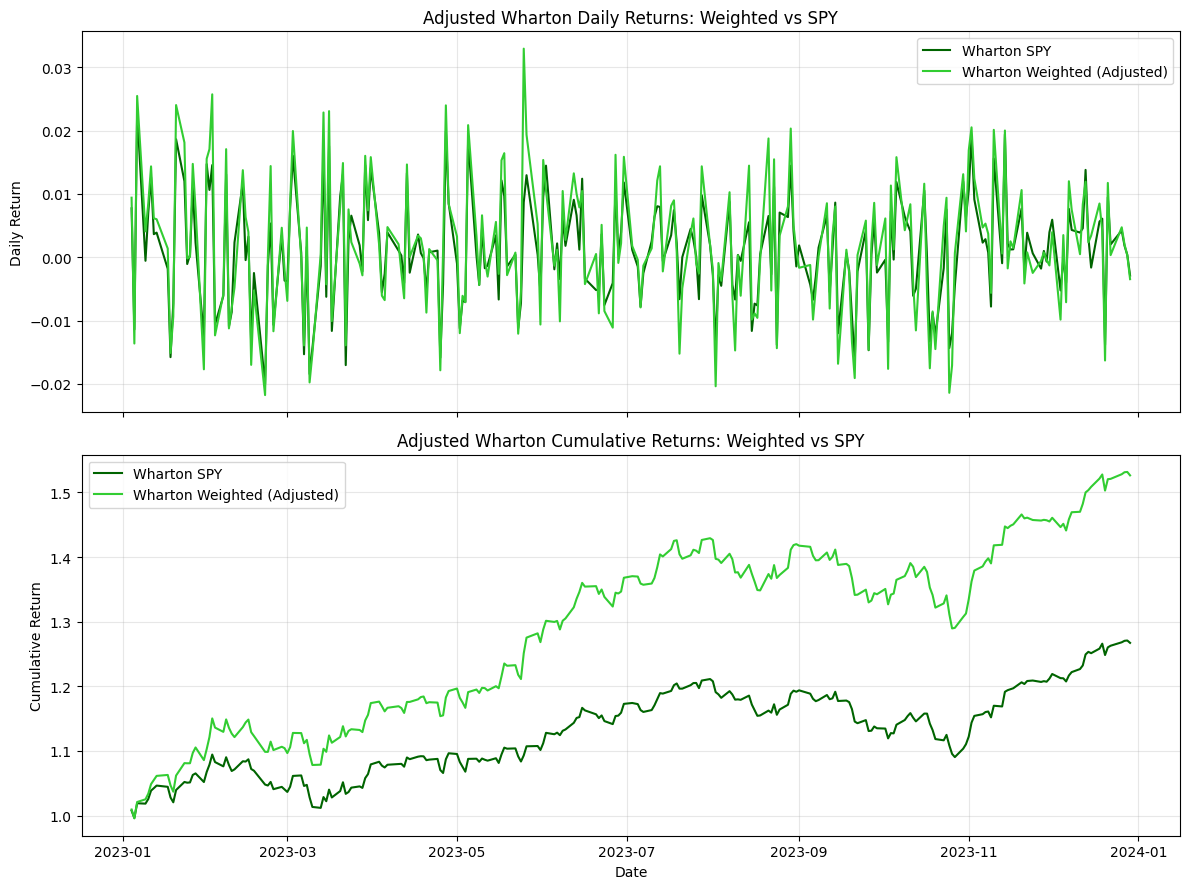

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from data_source import WhartonDataSource, YahooFinanceDataSource


def apply_alias_map(series: pd.Series, alias_map: dict) -> pd.Series:
    return series.astype(str).str.strip().str.upper().replace(alias_map)


def calculate_dynamic_weighted_portfolio(holdings_df: pd.DataFrame, price_data: pd.DataFrame) -> pd.Series:
    """
    Coverage-aware weighted portfolio:
    each day, renormalize weights over tickers that have a valid price that day.
    """
    weights = holdings_df[['Ticker', 'Weight']].copy()
    weights['Ticker'] = weights['Ticker'].astype(str).str.strip().str.upper()
    total_weight = weights['Weight'].sum()
    weights['NormWeight'] = weights['Weight'] / total_weight
    w = weights.set_index('Ticker')['NormWeight']

    common_cols = [c for c in price_data.columns if c in w.index]
    px = price_data[common_cols].copy().sort_index().ffill()

    # Normalize each ticker to first valid observation
    norm_px = px.copy()
    for col in norm_px.columns:
        first_valid = norm_px[col].first_valid_index()
        if first_valid is not None and norm_px.loc[first_valid, col] not in [0, None]:
            norm_px[col] = norm_px[col] / norm_px.loc[first_valid, col]

    weighted = []
    for dt, row in norm_px.iterrows():
        valid = row.dropna()
        if valid.empty:
            weighted.append((dt, float('nan')))
            continue
        day_w = w.reindex(valid.index).dropna()
        if day_w.sum() == 0:
            weighted.append((dt, float('nan')))
            continue
        day_w = day_w / day_w.sum()
        weighted.append((dt, (valid * day_w).sum()))

    return pd.Series(dict(weighted)).sort_index()


def verify_adjusted(spy_series: pd.Series, weighted_series: pd.Series, threshold: float = 0.01) -> dict:
    aligned = pd.concat([spy_series, weighted_series], axis=1).dropna()
    aligned.columns = ['SPY', 'Portfolio']

    norm_spy = aligned['SPY'] / aligned['SPY'].iloc[0]
    norm_port = aligned['Portfolio'] / aligned['Portfolio'].iloc[0]

    r_spy = norm_spy.pct_change().dropna()
    r_port = norm_port.pct_change().dropna()

    both = pd.concat([r_spy, r_port], axis=1).dropna()
    both.columns = ['SPY', 'Portfolio']

    diff = (both['SPY'] - both['Portfolio']).abs()

    return {
        'within_threshold': bool((diff <= threshold).all()),
        'max_difference': float(diff.max()),
        'mean_difference': float(diff.mean()),
        'spearman_coeff': float(both.corr(method='spearman').iloc[0, 1]),
        'pearson_coeff': float(both.corr(method='pearson').iloc[0, 1]),
        'p95_difference': float(diff.quantile(0.95)),
        'worst_days': diff.nlargest(5),
        'spy_returns': both['SPY'],
        'portfolio_returns': both['Portfolio'],
    }


start_date = '2023-01-01'
end_date = '2024-01-01'

alias_map_wharton = {
    'BRK-B': 'BRK.B',
    'BF-B': 'BF.B',
    'FI': 'FISV',
    'PARA': 'PARAA',
    '-': 'USD',
}

print('Loading holdings...')
yf_ds = YahooFinanceDataSource()
holdings = yf_ds.read_spy_holdings('holdings-daily-us-en-spy.xlsx')
holdings_w = holdings.copy()
holdings_w['Ticker'] = apply_alias_map(holdings_w['Ticker'], alias_map_wharton)

print('Loading Wharton prices...')
wh_ds = WhartonDataSource(use_trfd=True)
wh_tickers = ['SPY'] + holdings_w['Ticker'].tolist()
price_wh = wh_ds.get_historical_data(wh_tickers, start_date, end_date)

missing_after_alias = sorted(set(holdings_w['Ticker']) - set(price_wh.columns))
print(f'Missing after alias mapping: {len(missing_after_alias)}')
print('Missing list:', missing_after_alias)

if 'SPY' not in price_wh.columns:
    raise ValueError('SPY not found in Wharton data for requested window')

spy_wh = price_wh['SPY'].copy()
weighted_wh_dynamic = calculate_dynamic_weighted_portfolio(holdings_w, price_wh.drop(columns=['SPY'], errors='ignore'))

adj_results = verify_adjusted(spy_wh, weighted_wh_dynamic, threshold=0.01)
status = 'PASSED' if adj_results['within_threshold'] else 'FAILED'

print('\n--- Adjusted Wharton Verification ---')
print(f'Verification: {status}')
print(f"Max Difference: {adj_results['max_difference']*100:.4f}%")
print(f"Mean Difference: {adj_results['mean_difference']*100:.4f}%")
print(f"P95 Difference: {adj_results['p95_difference']*100:.4f}%")
print(f"Spearman Coeff: {adj_results['spearman_coeff']*100:.4f}%")
print(f"Pearson Coeff: {adj_results['pearson_coeff']*100:.4f}%")

print('Worst 5 days:')
for dt, val in adj_results['worst_days'].items():
    print(f'  {dt.date()}: {val*100:.4f}%')

# Plot adjusted Wharton weighted vs SPY
r_spy = adj_results['spy_returns']
r_port = adj_results['portfolio_returns']
common = r_spy.index.intersection(r_port.index)
r_spy = r_spy.loc[common]
r_port = r_port.loc[common]

c_spy = (1 + r_spy).cumprod()
c_port = (1 + r_port).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1.plot(common, r_spy, label='Wharton SPY', color='darkgreen')
ax1.plot(common, r_port, label='Wharton Weighted (Adjusted)', color='limegreen')
ax1.set_title('Adjusted Wharton Daily Returns: Weighted vs SPY')
ax1.set_ylabel('Daily Return')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(common, c_spy, label='Wharton SPY', color='darkgreen')
ax2.plot(common, c_port, label='Wharton Weighted (Adjusted)', color='limegreen')
ax2.set_title('Adjusted Wharton Cumulative Returns: Weighted vs SPY')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('spy_verification_wharton_adjusted_alias_dynamic.png', dpi=150)
print("Saved adjusted plot to 'spy_verification_wharton_adjusted_alias_dynamic.png'")


Loading static SPY holdings snapshot...
Initializing WhartonDataSource (default -> WhartonDataSource4)...
WhartonDataSource loaded 4232706 records for 831 tickers from /Users/bouse/developer/CDS/millennium-data-quality-25-26/backtester/WhartonDataSource4.parquet
Fetching Wharton prices for 506 tickers...
Complete constituents used: 497 / 505
Missing/partial dropped: 8
Dropped list: ['BF.B', 'GEV', 'KVUE', 'MMC', 'SNDK', 'SOLV', 'SW', 'VLTO']

--- Static Wharton Verification Metrics ---
Verification: FAILED
Max Difference: 2.4322%
Mean Difference: 0.2848%
Spearman Coeff: 94.5047%
Pearson Coeff: 94.5610%
Saved static verification plot to 'spy_verification_wharton_static_holdings.png'


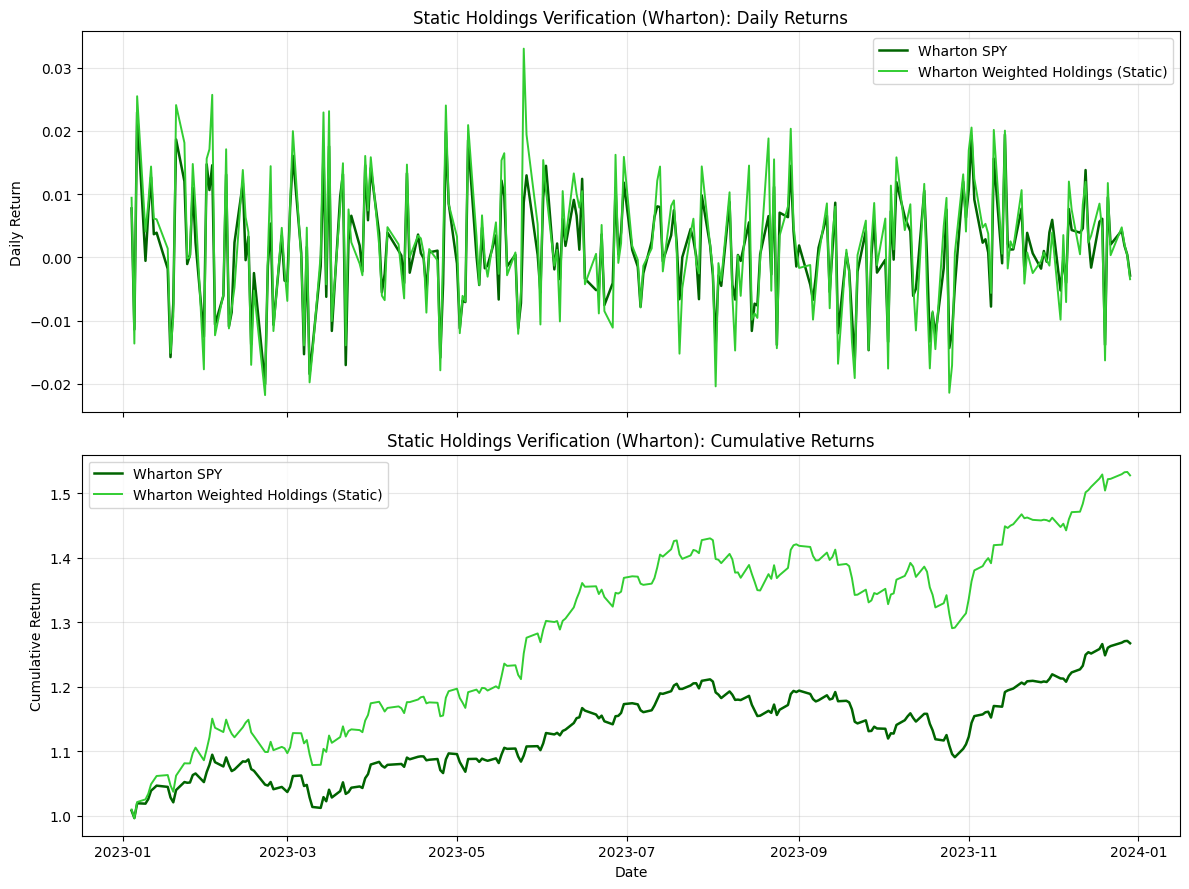

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from data_source import WhartonDataSource, YahooFinanceDataSource

# Static snapshot from State Street holdings file (same approach as Yahoo baseline)
# Use a more recent window.
start_date = '2024-01-01'
end_date = '2026-01-01'

print('Loading static SPY holdings snapshot...')
yf_ds = YahooFinanceDataSource()
holdings_df = yf_ds.read_spy_holdings('holdings-daily-us-en-spy.xlsx')

# Wharton ticker convention + pragmatic aliases for current symbols
holdings_df['Ticker'] = holdings_df['Ticker'].replace({
    'BRK.B': 'BRK.B',
    'BF.B': 'BF.B',
    'BF-B': 'BF.B',
    'FI': 'FISV',
    'PARA': 'PARAA',
    '-': 'USD',
})

print('Initializing WhartonDataSource (default -> WhartonDataSource4)...')
wharton_ds = WhartonDataSource(use_trfd=True)

tickers = ['SPY'] + holdings_df['Ticker'].tolist()
print(f'Fetching Wharton prices for {len(tickers)} tickers...')
price_data = wharton_ds.get_historical_data(tickers, start_date, end_date)

if 'SPY' not in price_data.columns:
    raise ValueError('SPY not found in Wharton dataset for this window.')

# Keep exactly the same methodology as the original Yahoo verification:
# drop columns with any NaN, then use existing weighted portfolio + verifier methods.
spy_data = price_data['SPY'].copy()
valid_columns = list(price_data.columns[price_data.isna().sum() == 0])
if 'SPY' not in valid_columns:
    valid_columns.append('SPY')

price_data = price_data[valid_columns]
valid_constituents = [t for t in valid_columns if t != 'SPY']
missing_or_partial = sorted(set(holdings_df['Ticker']) - set(valid_columns))

print(f'Complete constituents used: {len(valid_constituents)} / {len(holdings_df)}')
print(f'Missing/partial dropped: {len(missing_or_partial)}')
print('Dropped list:', missing_or_partial)

weighted_portfolio = yf_ds.calculate_weighted_portfolio(holdings_df, price_data)
verification = yf_ds.verify_spy_vs_constituents(spy_data, weighted_portfolio, threshold=0.01)

status = 'PASSED' if verification['within_threshold'] else 'FAILED'
print('\n--- Static Wharton Verification Metrics ---')
print(f'Verification: {status}')
print(f"Max Difference: {verification['max_difference']*100:.4f}%")
print(f"Mean Difference: {verification['mean_difference']*100:.4f}%")
print(f"Spearman Coeff: {verification['spearman_coeff']*100:.4f}%")
print(f"Pearson Coeff: {verification['pearson_coeff']*100:.4f}%")

spy_returns = spy_data.pct_change().dropna()
portfolio_returns = weighted_portfolio.pct_change().dropna()
common_dates = spy_returns.index.intersection(portfolio_returns.index)
spy_returns = spy_returns.loc[common_dates]
portfolio_returns = portfolio_returns.loc[common_dates]

cum_spy = (1 + spy_returns).cumprod()
cum_portfolio = (1 + portfolio_returns).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1.plot(common_dates, spy_returns, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax1.plot(common_dates, portfolio_returns, label='Wharton Weighted Holdings (Static)', color='limegreen', linewidth=1.4)
ax1.set_title('Static Holdings Verification (Wharton): Daily Returns')
ax1.set_ylabel('Daily Return')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(common_dates, cum_spy, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax2.plot(common_dates, cum_portfolio, label='Wharton Weighted Holdings (Static)', color='limegreen', linewidth=1.4)
ax2.set_title('Static Holdings Verification (Wharton): Cumulative Returns')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('spy_verification_wharton_static_holdings.png', dpi=150)
print("Saved static verification plot to 'spy_verification_wharton_static_holdings.png'")

## Reconciliation Path: GVKEY Bridge + Availability-Aware Weights


WhartonDataSource loaded 4232706 records for 831 tickers from /Users/bouse/developer/CDS/millennium-data-quality-25-26/backtester/WhartonDataSource4.parquet
--- Reconciled Wharton Verification ---
Max Difference: 1.3654%
Mean Difference: 0.1682%
P95 Difference: 0.4426%
Spearman: 97.3726%
Pearson: 98.2948%
Unmapped holdings tickers (no GVKEY after S&P500+GVKEY fallback): 1
PARA
Saved reconciled plot to 'spy_verification_wharton_reconciled_gvkey.png'


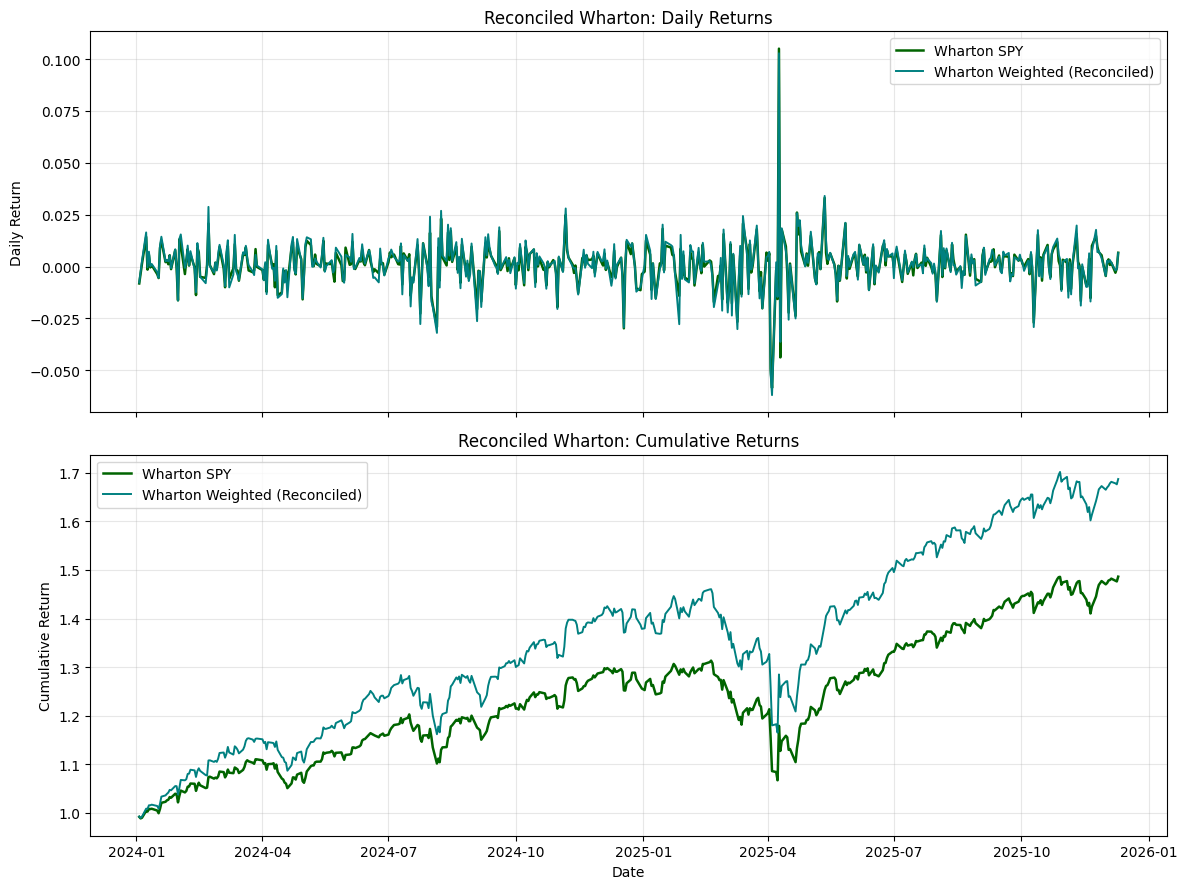

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from data_source import WhartonDataSource, YahooFinanceDataSource

start_date = '2024-01-01'
end_date = '2026-01-01'


def build_daily_available_weighted_portfolio(price_data: pd.DataFrame, holdings_weights: pd.Series) -> pd.Series:
    """Daily portfolio with original weights renormalized over available tickers each day."""
    px = price_data.sort_index().copy()
    norm = px.copy()

    for c in norm.columns:
        fv = norm[c].first_valid_index()
        if fv is not None and pd.notna(norm.loc[fv, c]) and norm.loc[fv, c] != 0:
            norm[c] = norm[c] / norm.loc[fv, c]

    out = {}
    for dt, row in norm.iterrows():
        avail = row.dropna()
        if avail.empty:
            out[dt] = float('nan')
            continue

        w = holdings_weights.reindex(avail.index).dropna()
        if w.empty or w.sum() == 0:
            out[dt] = float('nan')
            continue

        w = w / w.sum()
        out[dt] = (avail * w).sum()

    return pd.Series(out).sort_index()


def verify(spy_series: pd.Series, port_series: pd.Series) -> dict:
    aligned = pd.concat([spy_series, port_series], axis=1).dropna()
    aligned.columns = ['SPY', 'Portfolio']

    r_spy = (aligned['SPY'] / aligned['SPY'].iloc[0]).pct_change().dropna()
    r_port = (aligned['Portfolio'] / aligned['Portfolio'].iloc[0]).pct_change().dropna()
    both = pd.concat([r_spy, r_port], axis=1).dropna()
    both.columns = ['SPY', 'Portfolio']

    diff = (both['SPY'] - both['Portfolio']).abs()

    return {
        'max_difference': float(diff.max()),
        'mean_difference': float(diff.mean()),
        'p95_difference': float(diff.quantile(0.95)),
        'spearman': float(both.corr(method='spearman').iloc[0, 1]),
        'pearson': float(both.corr(method='pearson').iloc[0, 1]),
        'returns_spy': both['SPY'],
        'returns_port': both['Portfolio'],
    }


# 1) Static holdings snapshot
yf_ds = YahooFinanceDataSource()
holdings = yf_ds.read_spy_holdings('holdings-daily-us-en-spy.xlsx')
holdings['Ticker'] = holdings['Ticker'].astype(str).str.strip().str.upper()

# 2) Bridge holdings tickers -> GVKEY using S&P500 + GVKEY extract
sp500 = pd.read_csv('S&P500.csv', low_memory=False)
sp500['tic'] = sp500['tic'].astype(str).str.strip().str.upper()
sp500['gvkey'] = sp500['gvkey'].astype(str).str.strip()

gvkey_map = pd.read_csv('GVKEY.csv', low_memory=False)
gvkey_map['ticker'] = gvkey_map['ticker'].astype(str).str.strip().str.upper()
gvkey_map['gvkey'] = gvkey_map['gvkey'].astype(str).str.strip()
if 'primaryflag' in gvkey_map.columns:
    gvkey_map = gvkey_map.sort_values('primaryflag', ascending=False)
gvkey_map = gvkey_map.drop_duplicates('ticker')

ticker_fix = {
    'BRK-B': 'BRK.B',
    'BF-B': 'BF.B',
    'FI': 'FISV',
    'PARA': 'PARAA',
    '-': 'USD',
}
holdings['TickerNorm'] = holdings['Ticker'].replace(ticker_fix)

bridge = holdings.merge(sp500[['tic', 'gvkey']], left_on='TickerNorm', right_on='tic', how='left')
bridge = bridge.merge(
    gvkey_map[['ticker', 'gvkey']].rename(columns={'ticker': 'TickerNorm', 'gvkey': 'gvkey_fallback'}),
    on='TickerNorm',
    how='left',
)
bridge['gvkey'] = bridge['gvkey'].fillna(bridge['gvkey_fallback'])

# 3) Use Wharton to resolve actual tradable ticker per GVKEY in window
wh_raw = pd.read_parquet('WhartonDataSource4.parquet', columns=['gvkey', 'tic', 'datadate'])
wh_raw['gvkey'] = wh_raw['gvkey'].astype(str).str.strip()
wh_raw['tic'] = wh_raw['tic'].astype(str).str.strip().str.upper()
wh_raw['datadate'] = pd.to_datetime(wh_raw['datadate'])
wh_win = wh_raw[(wh_raw['datadate'] >= pd.Timestamp(start_date)) & (wh_raw['datadate'] <= pd.Timestamp(end_date))]

# per gvkey, choose ticker with most observations in window
counts = wh_win.groupby(['gvkey', 'tic']).size().reset_index(name='n_obs')
resolved = counts.sort_values(['gvkey', 'n_obs'], ascending=[True, False]).drop_duplicates('gvkey')
resolved = resolved.rename(columns={'tic': 'resolved_tic'})[['gvkey', 'resolved_tic', 'n_obs']]

bridge = bridge.merge(resolved, on='gvkey', how='left')

# fallback to normalized ticker when gvkey resolution missing
bridge['final_tic'] = bridge['resolved_tic'].fillna(bridge['TickerNorm'])

# 4) Pull prices for resolved set using existing WhartonDataSource logic
wh_ds = WhartonDataSource(use_trfd=True)
resolved_tickers = sorted(set(bridge['final_tic'].dropna().tolist()))
price = wh_ds.get_historical_data(['SPY'] + resolved_tickers, start_date, end_date)

spy = price['SPY'].copy()
price_const = price.drop(columns=['SPY'], errors='ignore')

# 5) Build daily availability-aware weighted portfolio using original static weights
weights = bridge.dropna(subset=['final_tic']).groupby('final_tic')['Weight'].sum()
weights = weights / weights.sum()
port = build_daily_available_weighted_portfolio(price_const, weights)

res = verify(spy, port)
print('--- Reconciled Wharton Verification ---')
print(f"Max Difference: {res['max_difference']*100:.4f}%")
print(f"Mean Difference: {res['mean_difference']*100:.4f}%")
print(f"P95 Difference: {res['p95_difference']*100:.4f}%")
print(f"Spearman: {res['spearman']*100:.4f}%")
print(f"Pearson: {res['pearson']*100:.4f}%")

unmapped = bridge[bridge['gvkey'].isna()]['Ticker'].dropna().unique().tolist()
print(f"Unmapped holdings tickers (no GVKEY after S&P500+GVKEY fallback): {len(unmapped)}")
print(' '.join(sorted(unmapped)[:40]))

# plotting
r_spy = res['returns_spy']
r_port = res['returns_port']
common = r_spy.index.intersection(r_port.index)
r_spy = r_spy.loc[common]
r_port = r_port.loc[common]

c_spy = (1 + r_spy).cumprod()
c_port = (1 + r_port).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1.plot(common, r_spy, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax1.plot(common, r_port, label='Wharton Weighted (Reconciled)', color='teal', linewidth=1.4)
ax1.set_title('Reconciled Wharton: Daily Returns')
ax1.set_ylabel('Daily Return')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(common, c_spy, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax2.plot(common, c_port, label='Wharton Weighted (Reconciled)', color='teal', linewidth=1.4)
ax2.set_title('Reconciled Wharton: Cumulative Returns')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('spy_verification_wharton_reconciled_gvkey.png', dpi=150)
print("Saved reconciled plot to 'spy_verification_wharton_reconciled_gvkey.png'")


## Dynamic Membership Verification (Using Join/Leave Dates)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from data_source import WhartonDataSource, YahooFinanceDataSource

# Dynamic-membership backtest window
start_date = '2024-01-01'
end_date = '2026-01-01'

# Ticker normalization into Wharton conventions
alias_map = {
    'BRK-B': 'BRK.B',
    'BF-B': 'BF.B',
    'FI': 'FISV',
    'PARA': 'PARAA',
    '-': 'USD',
}

def map_ticker(t):
    if pd.isna(t):
        return None
    t = str(t).strip().upper()
    if not t:
        return None
    t = alias_map.get(t, t)
    # Generic class-share normalization for Wharton format
    t = t.replace('-', '.')
    return t

# 1) Anchor universe: static holdings snapshot (current constituent snapshot)
yf_ds = YahooFinanceDataSource()
holdings_df = yf_ds.read_spy_holdings('holdings-daily-us-en-spy.xlsx')
anchor_universe = {map_ticker(t) for t in holdings_df['Ticker'].tolist()}
anchor_universe = {t for t in anchor_universe if t}

# 2) Load constituent changes and map tickers
changes = pd.read_csv('constituent_changes_parsed.csv', low_memory=False)
changes['effective_date'] = pd.to_datetime(changes['effective_date'])
changes['added_mapped'] = changes['added_ticker'].map(map_ticker)
changes['removed_mapped'] = changes['removed_ticker'].map(map_ticker)

# Keep only changes up to our end_date
changes = changes[changes['effective_date'] <= pd.Timestamp(end_date)].copy()
changes = changes.sort_values('effective_date')

# 3) Reconstruct daily active universe by walking backward from anchor at end_date
calendar = pd.date_range(start=start_date, end=end_date, freq='B')
current_set = set(anchor_universe)
active_by_date = {}

# Pre-group changes by date for reverse replay
chg_by_date = {}
for _, r in changes.iterrows():
    d = r['effective_date'].normalize()
    chg_by_date.setdefault(d, []).append((r['added_mapped'], r['removed_mapped']))

for d in sorted(calendar, reverse=True):
    # State on date d (close) before stepping back
    active_by_date[d] = set(current_set)

    # Reverse all changes that became effective on d
    if d in chg_by_date:
        for added, removed in chg_by_date[d]:
            # Forward rule: added enters, removed leaves on effective_date
            # Reverse step (to previous day): remove added, restore removed
            if added and added in current_set:
                current_set.remove(added)
            if removed:
                current_set.add(removed)

# 4) Pull Wharton prices for union of all active names + SPY
all_dynamic_names = sorted(set().union(*active_by_date.values()))
wharton_ds = WhartonDataSource(use_trfd=True)
price_data = wharton_ds.get_historical_data(['SPY'] + all_dynamic_names, start_date, end_date)

if 'SPY' not in price_data.columns:
    raise ValueError('SPY not found in Wharton data for dynamic verification window.')

# 5) Build equal-weight dynamic portfolio (daily active set, available-price names only)
const_prices = price_data.drop(columns=['SPY'], errors='ignore').sort_index()
const_norm = const_prices.copy()
for c in const_norm.columns:
    fv = const_norm[c].first_valid_index()
    if fv is not None and pd.notna(const_norm.loc[fv, c]) and const_norm.loc[fv, c] != 0:
        const_norm[c] = const_norm[c] / const_norm.loc[fv, c]

portfolio_series = []
coverage_stats = []
for d in const_norm.index:
    active = active_by_date.get(pd.Timestamp(d).normalize(), set())
    if not active:
        portfolio_series.append((d, float('nan')))
        coverage_stats.append((d, 0, 0))
        continue

    candidates = [t for t in active if t in const_norm.columns]
    if not candidates:
        portfolio_series.append((d, float('nan')))
        coverage_stats.append((d, len(active), 0))
        continue

    row = const_norm.loc[d, candidates].dropna()
    used = len(row)
    total = len(active)
    coverage_stats.append((d, total, used))

    if used == 0:
        portfolio_series.append((d, float('nan')))
        continue

    # Equal weight over available active names (no historical weights file)
    portfolio_series.append((d, row.mean()))

dynamic_portfolio = pd.Series(dict(portfolio_series)).sort_index()
coverage_df = pd.DataFrame(coverage_stats, columns=['date', 'active_total', 'active_used']).set_index('date')
coverage_df['coverage_ratio'] = coverage_df['active_used'] / coverage_df['active_total'].replace(0, pd.NA)

# 6) Verify vs SPY
spy_series = price_data['SPY']
aligned = pd.concat([spy_series, dynamic_portfolio], axis=1).dropna()
aligned.columns = ['SPY', 'Dynamic']

norm_spy = aligned['SPY'] / aligned['SPY'].iloc[0]
norm_dyn = aligned['Dynamic'] / aligned['Dynamic'].iloc[0]

ret_spy = norm_spy.pct_change().dropna()
ret_dyn = norm_dyn.pct_change().dropna()
ret_both = pd.concat([ret_spy, ret_dyn], axis=1).dropna()
ret_both.columns = ['SPY', 'Dynamic']

diff = (ret_both['SPY'] - ret_both['Dynamic']).abs()

print('--- Dynamic Membership (Join/Leave) Verification ---')
print(f'Window: {start_date} to {end_date}')
print(f'Max diff: {diff.max()*100:.4f}%')
print(f'Mean diff: {diff.mean()*100:.4f}%')
print(f'P95 diff: {diff.quantile(0.95)*100:.4f}%')
print(f"Spearman: {ret_both.corr(method='spearman').iloc[0,1]*100:.4f}%")
print(f"Pearson: {ret_both.corr(method='pearson').iloc[0,1]*100:.4f}%")
print(f"Avg active names used/day: {coverage_df['active_used'].mean():.1f}")
print(f"Avg coverage ratio: {coverage_df['coverage_ratio'].mean()*100:.2f}%")

# 7) Plot dynamic portfolio vs SPY
cum_spy = (1 + ret_both['SPY']).cumprod()
cum_dyn = (1 + ret_both['Dynamic']).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1.plot(ret_both.index, ret_both['SPY'], label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax1.plot(ret_both.index, ret_both['Dynamic'], label='Wharton Dynamic Membership (EW)', color='purple', linewidth=1.3)
ax1.set_title('Dynamic Membership (Join/Leave): Daily Returns')
ax1.set_ylabel('Daily Return')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(cum_spy.index, cum_spy, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax2.plot(cum_dyn.index, cum_dyn, label='Wharton Dynamic Membership (EW)', color='purple', linewidth=1.3)
ax2.set_title('Dynamic Membership (Join/Leave): Cumulative Returns')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('spy_verification_wharton_dynamic_membership.png', dpi=150)
print("Saved dynamic-membership plot to 'spy_verification_wharton_dynamic_membership.png'")


TypeError: '<' not supported between instances of 'float' and 'str'

## Dynamic Membership + Monthly Cap-Weight Proxy


/var/folders/8w/9mf859k53sz7fy52lp0624b40000gn/T/ipykernel_3461/3926165416.py:136: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  both = pd.concat([spy_ret, dynamic_port_ret], axis=1).dropna()


--- Dynamic Membership + Monthly Cap-Weight Proxy ---
Window: 2024-01-01 to 2026-01-01
Max diff: 0.9133%
Mean diff: 0.0770%
P95 diff: 0.2585%
Spearman: 98.5679%
Pearson: 99.2785%
Rebalance points used: 24
Final cumulative SPY: 1.4547
Final cumulative DynamicCapProxy: 1.4257
Saved dynamic cap-proxy plot to 'spy_verification_wharton_dynamic_membership_monthly_cap_proxy.png'


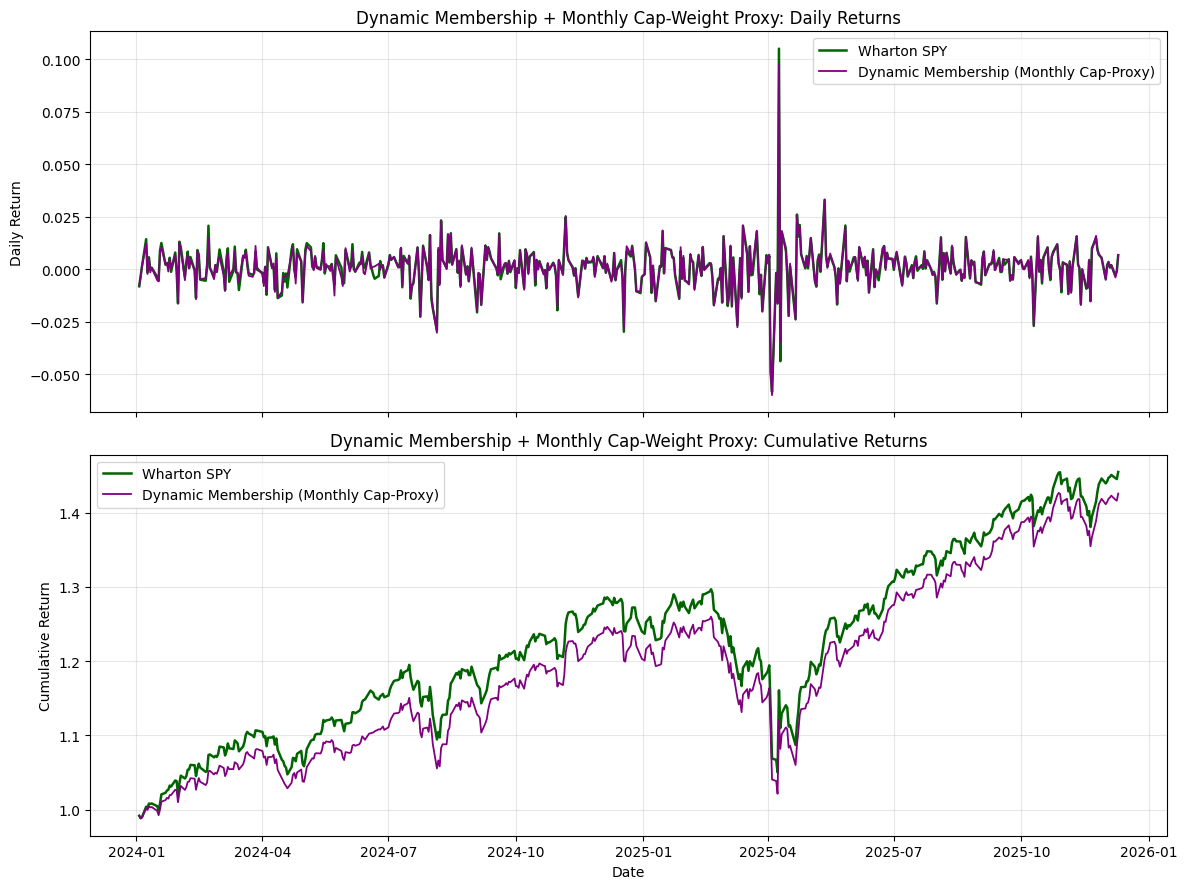

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from data_source import WhartonDataSource, YahooFinanceDataSource

start_date = '2024-01-01'
end_date = '2026-01-01'

alias_map = {
    'BRK-B': 'BRK.B',
    'BF-B': 'BF.B',
    'FI': 'FISV',
    'PARA': 'PARAA',
    '-': 'USD',
}

def map_ticker(t):
    if pd.isna(t):
        return None
    t = str(t).strip().upper()
    if not t:
        return None
    t = alias_map.get(t, t)
    return t.replace('-', '.')

# Load anchor holdings and changes
yf_ds = YahooFinanceDataSource()
holdings_df = yf_ds.read_spy_holdings('holdings-daily-us-en-spy.xlsx')
anchor_universe = {map_ticker(t) for t in holdings_df['Ticker'].tolist()}
anchor_universe = {t for t in anchor_universe if t}

changes = pd.read_csv('constituent_changes_parsed.csv', low_memory=False)
changes['effective_date'] = pd.to_datetime(changes['effective_date'])
changes['added_mapped'] = changes['added_ticker'].map(map_ticker)
changes['removed_mapped'] = changes['removed_ticker'].map(map_ticker)
changes = changes[changes['effective_date'] <= pd.Timestamp(end_date)].sort_values('effective_date')

# Build active universe by date (reverse replay)
calendar = pd.date_range(start=start_date, end=end_date, freq='B')
current_set = set(anchor_universe)
active_by_date = {}
chg_by_date = {}
for _, r in changes.iterrows():
    d = r['effective_date'].normalize()
    chg_by_date.setdefault(d, []).append((r['added_mapped'], r['removed_mapped']))

for d in sorted(calendar, reverse=True):
    active_by_date[d] = set(current_set)
    if d in chg_by_date:
        for added, removed in chg_by_date[d]:
            if isinstance(added, str) and added in current_set:
                current_set.remove(added)
            if isinstance(removed, str) and removed:
                current_set.add(removed)

# Guard against mixed/non-string ticker values before sorting
all_dynamic_names = sorted(
    {
        t.strip().upper()
        for names in active_by_date.values()
        for t in names
        if isinstance(t, str) and t.strip()
    }
)

# Load raw Wharton fields for cap-weight proxy
raw = pd.read_parquet('WhartonDataSource4.parquet', columns=['tic', 'datadate', 'prccd', 'ajexdi', 'cshoc'])
raw['tic'] = raw['tic'].astype(str).str.strip().str.upper()
raw['datadate'] = pd.to_datetime(raw['datadate'])
raw = raw[(raw['datadate'] >= pd.Timestamp(start_date)) & (raw['datadate'] <= pd.Timestamp(end_date))]
raw = raw[raw['tic'].isin(all_dynamic_names + ['SPY'])]

# Price proxy
raw['split_adj_close'] = raw['prccd'] / raw['ajexdi']

# Market-cap proxy: price * shares if cshoc exists, fallback to price-only
raw['size_proxy'] = raw['split_adj_close']
mask_shares = raw['cshoc'].notna() & (raw['cshoc'] > 0)
raw.loc[mask_shares, 'size_proxy'] = raw.loc[mask_shares, 'split_adj_close'] * raw.loc[mask_shares, 'cshoc']

price_wide = raw.pivot(index='datadate', columns='tic', values='split_adj_close').sort_index()
size_wide = raw.pivot(index='datadate', columns='tic', values='size_proxy').sort_index()

# Daily return matrix from price proxy
ret = price_wide.pct_change()

# Monthly rebalance dates: first business day observed each month
month_key = pd.Series(price_wide.index.to_period('M'), index=price_wide.index)
rebalance_dates = month_key.groupby(month_key).apply(lambda s: s.index.min()).tolist()
rebalance_dates = sorted([d for d in rebalance_dates if d in price_wide.index])

# Compute monthly cap-proxy weights over active set
weights_by_reb = {}
for d in rebalance_dates:
    active = active_by_date.get(pd.Timestamp(d).normalize(), set())
    if not active:
        continue
    cands = [t for t in active if t in size_wide.columns]
    if not cands:
        continue
    vec = size_wide.loc[d, cands].dropna()
    vec = vec[vec > 0]
    if vec.empty:
        continue
    w = vec / vec.sum()
    weights_by_reb[d] = w

# Roll-forward monthly weights to each business day
all_days = ret.index
dynamic_port_ret = pd.Series(index=all_days, dtype=float)

current_w = None
reb_i = 0
rebalance_dates_sorted = sorted(weights_by_reb.keys())

for d in all_days:
    while reb_i < len(rebalance_dates_sorted) and rebalance_dates_sorted[reb_i] <= d:
        current_w = weights_by_reb[rebalance_dates_sorted[reb_i]]
        reb_i += 1

    if current_w is None:
        continue

    # Use available returns only; renormalize within available names
    row = ret.loc[d, current_w.index].dropna()
    if row.empty:
        continue
    w_day = current_w.reindex(row.index).dropna()
    if w_day.sum() == 0:
        continue
    w_day = w_day / w_day.sum()
    dynamic_port_ret.loc[d] = (row * w_day).sum()

# SPY returns from same price proxy
spy_ret = ret['SPY'].dropna() if 'SPY' in ret.columns else pd.Series(dtype=float)

both = pd.concat([spy_ret, dynamic_port_ret], axis=1).dropna()
both.columns = ['SPY', 'DynamicCapProxy']
diff = (both['SPY'] - both['DynamicCapProxy']).abs()

print('--- Dynamic Membership + Monthly Cap-Weight Proxy ---')
print(f'Window: {start_date} to {end_date}')
print(f'Max diff: {diff.max()*100:.4f}%')
print(f'Mean diff: {diff.mean()*100:.4f}%')
print(f'P95 diff: {diff.quantile(0.95)*100:.4f}%')
print(f"Spearman: {both.corr(method='spearman').iloc[0,1]*100:.4f}%")
print(f"Pearson: {both.corr(method='pearson').iloc[0,1]*100:.4f}%")
print(f"Rebalance points used: {len(weights_by_reb)}")

cum_spy = (1 + both['SPY']).cumprod()
cum_dyn = (1 + both['DynamicCapProxy']).cumprod()
print(f"Final cumulative SPY: {cum_spy.iloc[-1]:.4f}")
print(f"Final cumulative DynamicCapProxy: {cum_dyn.iloc[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1.plot(both.index, both['SPY'], label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax1.plot(both.index, both['DynamicCapProxy'], label='Dynamic Membership (Monthly Cap-Proxy)', color='purple', linewidth=1.3)
ax1.set_title('Dynamic Membership + Monthly Cap-Weight Proxy: Daily Returns')
ax1.set_ylabel('Daily Return')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(cum_spy.index, cum_spy, label='Wharton SPY', color='darkgreen', linewidth=1.8)
ax2.plot(cum_dyn.index, cum_dyn, label='Dynamic Membership (Monthly Cap-Proxy)', color='purple', linewidth=1.3)
ax2.set_title('Dynamic Membership + Monthly Cap-Weight Proxy: Cumulative Returns')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('spy_verification_wharton_dynamic_membership_monthly_cap_proxy.png', dpi=150)
print("Saved dynamic cap-proxy plot to 'spy_verification_wharton_dynamic_membership_monthly_cap_proxy.png'")
